Shapes: (2000, 100, 100, 3) (2000,)
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 267ms/step - accuracy: 0.5060 - loss: 0.7326 - val_accuracy: 0.5200 - val_loss: 0.6928
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 253ms/step - accuracy: 0.5150 - loss: 0.7268 - val_accuracy: 0.5200 - val_loss: 0.6998
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.5080 - loss: 0.6998 - val_accuracy: 0.4800 - val_loss: 0.7486
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 251ms/step - accuracy: 0.4950 - loss: 0.7029 - val_accuracy: 0.5200 - val_loss: 0.6923
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.4930 - loss: 0.7167 - val_accuracy: 0.5200 - val_loss: 0.6923
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 253ms/step - accuracy: 0.5215 - loss: 0.7000 - val_accuracy: 0.5200 - val_loss: 0.7067
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 249ms/step - accuracy: 0.5220 - loss: 0.6970 - val_accuracy: 0.4800 - val_loss: 0.6984
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 254ms/step - accura

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.001022409..0.0024437003].


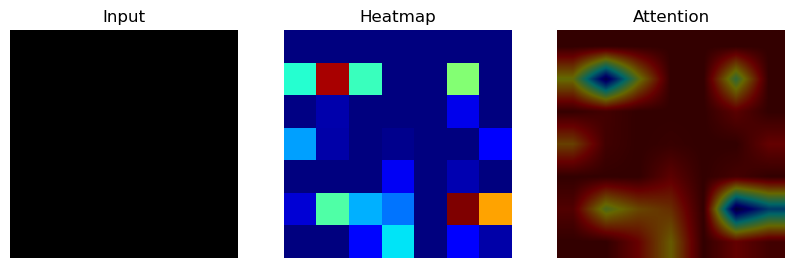

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.001027777..0.002412079].


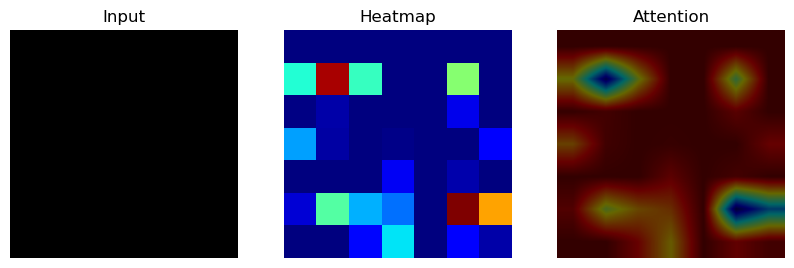

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0010183504..0.002390292].


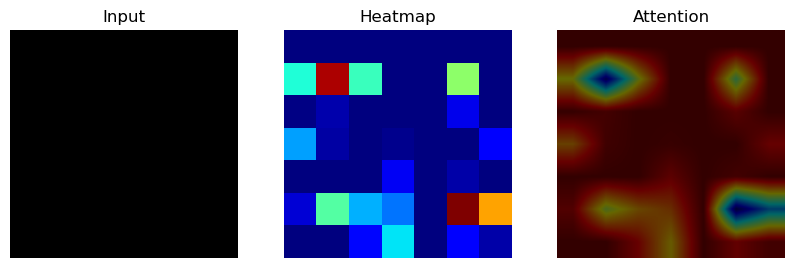

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0010158054..0.0024501104].


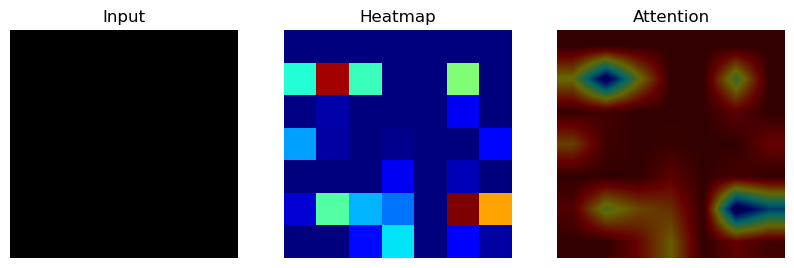

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.001020434..0.0023934303].


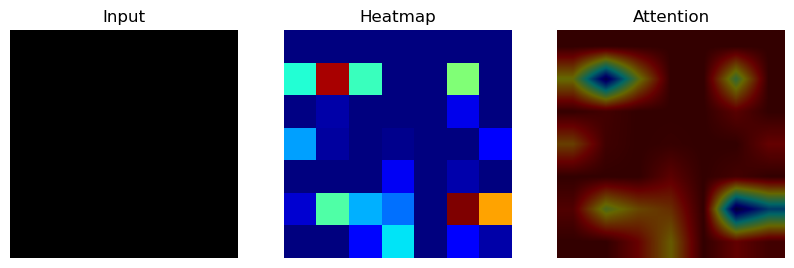

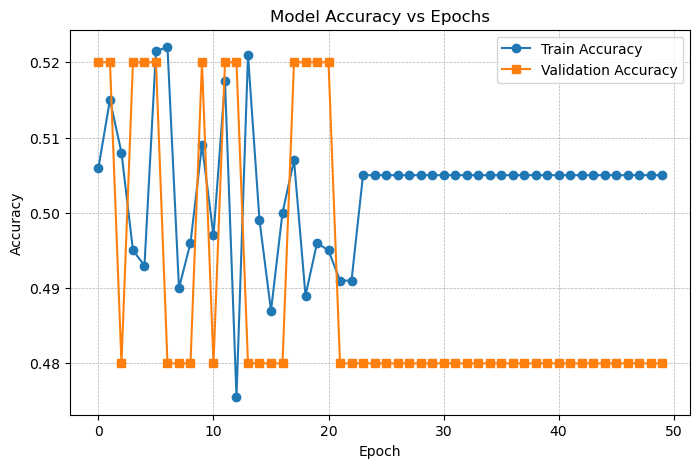

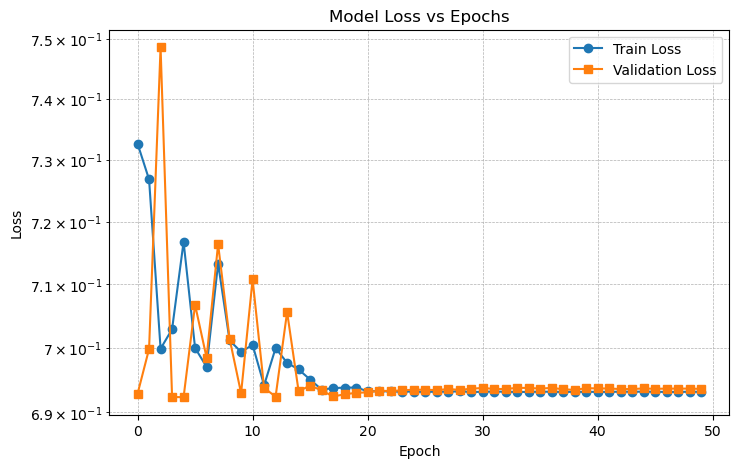

In [21]:
# =========================================
# 1. Imports
# =========================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.utils import to_categorical


# =========================================
# 2. Load Dataset
# =========================================
PATH = "C:/Users/gsama/Desktop/mobinet"

X_train = np.load(f"{PATH}/X_train.npy")
y_train = np.load(f"{PATH}/y_train.npy")
X_test = np.load(f"{PATH}/X_test.npy")
y_test = np.load(f"{PATH}/y_test.npy")

print("Shapes:", X_train.shape, y_train.shape)


# =========================================
# 3. RGB → YCgCr
# =========================================
def rgb_to_ycgcr(img):
    R = img[:,:,:,0]
    G = img[:,:,:,1]
    B = img[:,:,:,2]

    Y  = 0.25*R + 0.5*G + 0.25*B
    Cg = -0.25*R + 0.5*G - 0.25*B
    Cr = 0.5*R - 0.5*B

    return np.stack((Y, Cg, Cr), axis=-1)

X_train = rgb_to_ycgcr(X_train)
X_test = rgb_to_ycgcr(X_test)


# =========================================
# 4. Preprocessing
# =========================================
X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

X_train = tf.image.resize(X_train, (224,224)).numpy()
X_test = tf.image.resize(X_test, (224,224)).numpy()


# =========================================
# 5. Build MobileNet Model
# =========================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(y_train.shape[1], activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# =========================================
# 6. Train (50 Epochs)
# =========================================
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)


# =========================================
# 7. Save Model
# =========================================
model.save(f"{PATH}/mobilenet_ycgcr_final.keras")


# =========================================
# 8. Grad-CAM Setup
# =========================================
base_model = model.layers[1]
last_conv_layer = base_model.get_layer("Conv_1")

# Conv model
conv_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=last_conv_layer.output
)

# Classifier model
classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])

x = classifier_input
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = model.layers[3](x)
x = model.layers[4](x)

classifier_model = tf.keras.Model(classifier_input, x)


def make_gradcam_heatmap(img_array):
    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)

        preds = classifier_model(conv_outputs)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-8)
    return heatmap


# =========================================
# 9. Overlay Function
# =========================================
def overlay_heatmap(img, heatmap):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return np.uint8(heatmap * 0.4 + img)


# =========================================
# 10. Grad-CAM Visualization
# =========================================
for i in range(5):
    img = X_test[i]
    img_input = np.expand_dims(img, axis=0)

    heatmap = make_gradcam_heatmap(img_input)
    overlay = overlay_heatmap((img*255).astype(np.uint8), heatmap)

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Input")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Heatmap")
    plt.imshow(heatmap, cmap='jet')
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Attention")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()


# =========================================
# 11. Accuracy Plot (with grid)
# =========================================
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')

plt.title("Model Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.show()


# =========================================
# 12. Loss Plot (with grid + log scale)
# =========================================
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='s', label='Validation Loss')

plt.title("Model Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.yscale('log')

plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()